In [2]:
import sys
sys.path.append("../src")
import shap
import matplotlib.pyplot as plt
import explain as ex

ticker = "SBIN"
explainer, shap_values, X_sample, feat_cols = ex.build_explainer(ticker, sample_size=500)
print(X_sample.shape)

(500, 31)


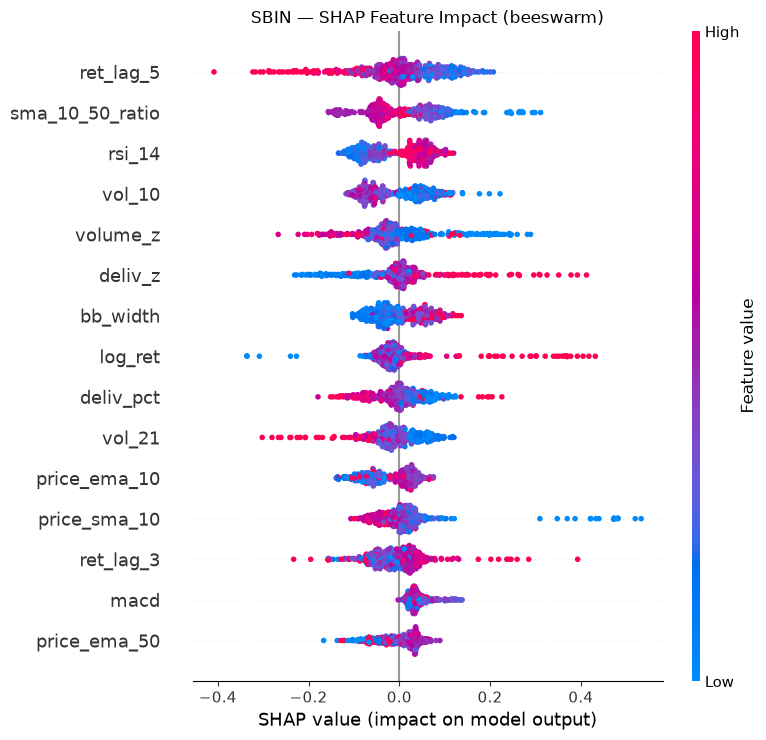

In [3]:
# Beeswarm
shap.summary_plot(shap_values, X_sample, feature_names=feat_cols,
                  max_display=15, show=False)
plt.title(f"{ticker} — SHAP Feature Impact (beeswarm)", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_beeswarm_SBIN.png", dpi=150, bbox_inches="tight")
plt.show()

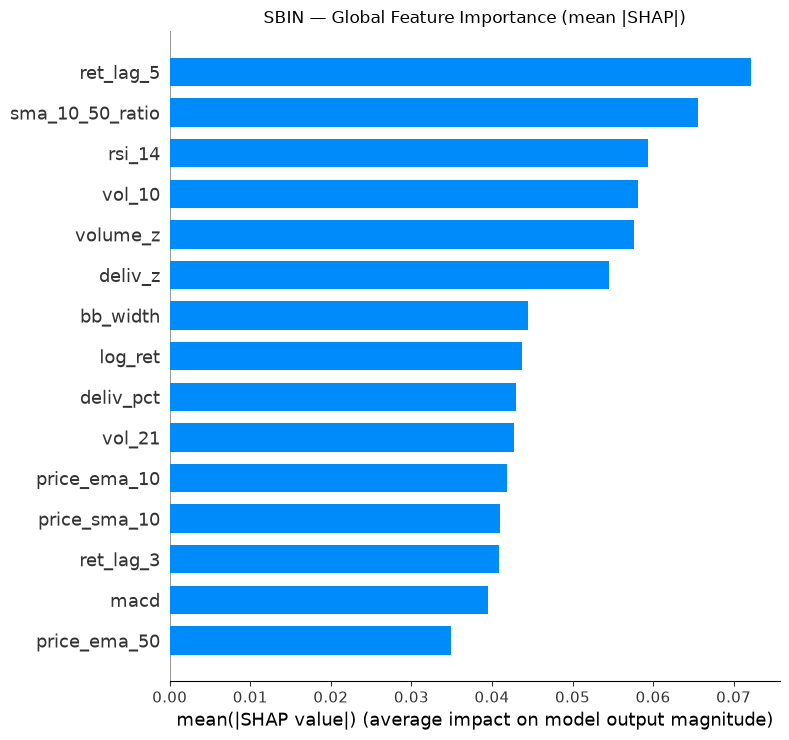

In [4]:
# Bar
shap.summary_plot(shap_values, X_sample, feature_names=feat_cols,
                  plot_type="bar", max_display=15, show=False)
plt.title(f"{ticker} — Global Feature Importance (mean |SHAP|)", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_importance_SBIN.png", dpi=150, bbox_inches="tight")
plt.show()

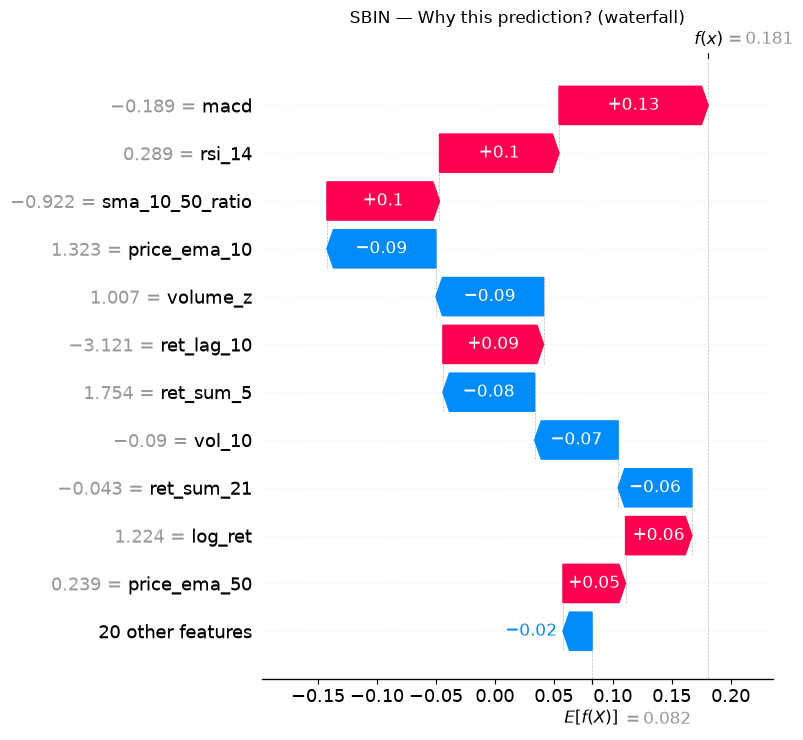

In [5]:
# ── Waterfall
import numpy as np
idx = -1
expl = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_sample.iloc[idx].values,
    feature_names=feat_cols,
)
shap.plots.waterfall(expl, max_display=12, show=False)
plt.title(f"{ticker} — Why this prediction? (waterfall)", fontsize=12)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_waterfall_SBIN.png", dpi=150, bbox_inches="tight")
plt.show()